## Background
The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

The equivalence is as follows (and a brief derivation will be detailed at a later time):

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} + \mathcal{G}^{\text{(num)}} = \mathcal{G}^{\text{(mix)}}
\end{equation}
$$

We have two separate methods for calculating $\mathcal{G}^{\text{(mix)}}$: using the convergence of a diffusive flux $\mathcal{F}$, or by using the tracer variance decay rate $\chi$. It then follows that 

$$
\begin{align}
     \mathcal{G}_\mathcal{F}^{\text{(phy)}} + \mathcal{G}_\mathcal{F}^{\text{(num)}} &= \mathcal{G}_\mathcal{F}^{\text{(mix)}} = \mathcal{G}^{\text{(mix)}} \\
     \mathcal{G}_\chi^{\text{(phy)}} + \mathcal{G}_\chi^{\text{(num)}} &= \mathcal{G}_\chi^{\text{(mix)}} = \mathcal{G}^{\text{(mix)}}\\
     \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} &= \mathcal{G}_\chi^{\text{(phy)}} \\
     \mathcal{G}_\mathcal{F}^{\text{(num)}} &= \mathcal{G}_\chi^{\text{(num)}} 
\end{align}
$$

The actual calculations for $\mathcal{G}_\mathcal{F}^{\text{(mix)}}$ and $\mathcal{G}_\chi^{\text{(mix)}}$ are as follows.
### $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$ 

>- use the tracer mass tendency output `salinityVertMixTendency` $= \mathcal{F} = -\nabla \cdot \left(-\kappa_{phy}\nabla \lambda \right)$ for $\kappa_{phy} = 10^{-5} \, m^2 s^{-1}$ (set by KPP; vertical mixing is parameterized in this simulation), and where $\lambda$ is the tracer (salinity, in this case).
>- $\Omega(\tilde\lambda, t)$ represents the volume defining the water mass $\mathcal{M}_\geq$

$$
\begin{equation}
    \mathcal{G}_\mathcal{F}^\text{(phy)} = \frac{\partial}{\partial \lambda} \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \, \text{d}V
\end{equation}
$$

### $\mathcal{G}_\mathcal{F}^{\text{(num)}}$ 
>- We cannot directly calculate $\mathcal{F}^{\text{(num)}}$
>- Instead, we can calculate as the residual of the water mass transformation budget, given a known $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$.
>- This works in this idealized simulation because we know that there is no surface tracer flux $\mathcal{S}$ (`salinitySurfaceFluxTendency` = 0 $\forall \, \mathbf{x}, t$), and there is no transport ($\Psi=0$) if we define the region $\mathcal{R}$ to be the entire domain such that boundary of the water mass $\mathcal{M}_\geq$ is the isosurface $\mathcal{A_R}$.

$$
\begin{align}
    \partial_t \mathcal{M}_\geq &= \Psi + \mathcal{S} + \mathcal{G}_\mathcal{F}^{\text{(phy)}} + \mathcal{G}_\mathcal{F}^{\text{(num)}} \\
    \implies \mathcal{G}_\mathcal{F}^{\text{(num)}} &= \partial_t \mathcal{M}_\geq - \mathcal{G}_\mathcal{F}^{\text{(phy)}}
\end{align}
$$

### $\mathcal{G}_\chi^{\text{(phy)}}$ 
>- use the tracer variance decay rate `chiPhyVerSalt_center` $= \chi^{\text{(phy)}} = -2 \kappa_{phy} \left( \frac{\partial \lambda}{\partial z}\right)^2 $.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = -\frac{1}{2} \partial_\lambda^2 \int_{\Omega(\tilde\lambda,t} \rho \chi^{\text{(phy)}} \, \text{d}V
\end{equation}
$$

### $\mathcal{G}_\chi^{\text{(num)}}$ 
>- We can calculate `chiSpurSaltBR08` $= \chi^{\text{(num)}}$ using the discrete variance decay algorithm

$$
\begin{equation}
    \chi^{\text{(num)}} = 2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}
\end{equation}
$$
>- where $\kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x} \right)$ (from algorithm)
>- We can then calculate $\mathcal{G}_\chi^{\text{(num)}}$  as

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(num)}} = -\frac{1}{2} \partial_\lambda^2 \int_{\Omega(\tilde\lambda,t} \rho \chi^{\text{(num)}} \, \text{d}V
\end{equation}
$$

In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid
from datetime import datetime

## Open files & visualize raw data

Note that we will be finite-differencing mass = `density * layerThickness` over time to get the mass evolution for the LHS of the budget equation. This means that we are actually calculating $\partial_t \mathcal{M}_\geq$ at time $t=i+1/2$, rather than at $t = i$ when we calculate using snapshots in time `ss_ds_output`. As a result, we also want our diagnostic variables $\mathcal{G}^{\text{(mix)}}$ to sit on the $i+1/2$ time interval. To achieve, this, we output the time-averaged datavariables `avg_ds_output` (see `avg-ds_output.Time`). 

In [2]:
def rename_time_avg_vars(avg_ds_output):
    old_name_array = []
    new_name_array = []
    
    for i in avg_ds_output.data_vars:
        old_name_array.append(i)
        if 'timeCustom' in i:
            new_name = i.replace('timeCustom_avg_' , '')
            if 'Tracer' in new_name:
                new_name = new_name.split('_')[1]
        else:
            new_name = i                
        new_name_array.append(new_name)
    
    new_name_dict = dict(zip(old_name_array, new_name_array))

    return new_name_dict

### NB with results from simulations run without vertical advection

Changed the following in `namelist.ocean_no_adv`

- 60 day, dt = 10 mins, output interval = 2 hours
- time_varying_wind = .false. (namelist)
- ran without immutable streams = "atmospheric forcing"
- `config_disable_thick_vadv = .true.`
- `config_disable_vel_vadv = .true.`
- `config_disable_vel_all_tend = .true.`
- `config_disable_thick_hadv = .true.`
- `config_disable_vel_hadv = .true.`
- `config_disable_tr_adv = .true.`
- run without vertical advection turned on; vertical advection is not part of the advection operator
- corresponding namelist has suffix "no_adv"

In [3]:
sim_res = '10km'
filepath = f'/pscratch/sd/k/kuyeda/WMT_DVD/bichan/{sim_res}/'

suffix = '_12day_HF_no_adv_no_ALE_no_diff' # '_with_vertAdv' #'_12day_HF_no_adv_no_ALE' #_12day_HF_no_adv_no_ALE_no_diff' # '_with_vertAdv' # '_12day_HF_no_adv' # '_12day_HF' '_with_vertAdv '_no_adv'
# averaged values (time = 10*n + 5)
avg_ds_output = xr.open_dataset(filepath + f'/analysis_members/mpaso.hist.am.timeSeriesStatsCustomAvg_{sim_res}_channel.0001-01-01.nc' + suffix,decode_times=False)

# rename variables to remove the "timeCustom_avg" and "activeTracer__" prefixes
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)

# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'fill', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# snapshots at every timestep (dt = 10 mins)
ss_ds_output = xr.open_dataset(filepath + f'{sim_res}_channel_output.nc' + suffix,decode_times=False)

# assign nVertLevelsP1 coordinates
ss_ds_output = ss_ds_output.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1})

# interpolate salinity onto nVertLevelsP1
ss_ds_grid = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'fill', 
                   autoparse_metadata = False)

ss_ds_output['salinity_P1'] = ss_ds_grid.interp(ss_ds_output.salinity, 'Z', padding = 'extend')

# ffill (good practice but not applicable here because no bathymetry)
ss_ds_output['salinity'] = ss_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

mesh = xr.open_dataset(filepath + f'{sim_res}_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

time_idx = 500

In [4]:
for i in avg_ds_output.data_vars:
    if 'BR08' in i:
        print(i)

chiSpurTempBR08
chiSpurSaltBR08


In [5]:
for i in avg_ds_output.data_vars:
    if 'urface' in i:
        print(i)

temperatureSurfaceFluxTendency
salinitySurfaceFluxTendency


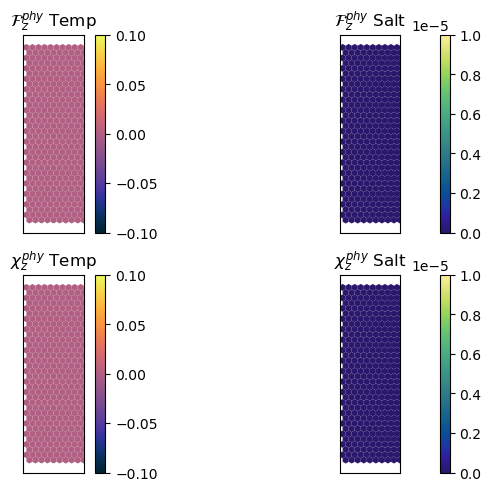

In [6]:
# comparison of mixing
fig,ax = plt.subplots(nrows=2, ncols = 2, constrained_layout=True)
time_idx = 200

# calculated as convergence of diffusive flux
a = mosaic.polypcolor(ax[0,0],descriptor, avg_ds_output.temperatureVertMixTendency.isel(Time=time_idx, nVertLevels=0), cmap='cmo.thermal')
b = mosaic.polypcolor(ax[0,1],descriptor, avg_ds_output.salinityVertMixTendency.isel(Time=time_idx, nVertLevels=0),cmap='cmo.haline', vmin=0, vmax=1e-5)
ax[0,0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[0,1].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')

# calculated as tracer variance decay
c = mosaic.polypcolor(ax[1,0],descriptor, avg_ds_output.chiPhyVerTemp_center.isel(Time=time_idx, nVertLevels=0), cmap='cmo.thermal')
d = mosaic.polypcolor(ax[1,1],descriptor, avg_ds_output.chiPhyVerSalt_center.isel(Time=time_idx, nVertLevels=0), cmap='cmo.haline', vmin=0, vmax=1e-5)
ax[1,0].set_title(r'$\chi_z^{phy}$ Temp')
ax[1,1].set_title(r'$\chi_z^{phy}$ Salt')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_aspect(1.0)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

fig.colorbar(a, ax = ax[0,0])
fig.colorbar(b, ax = ax[0,1])
fig.colorbar(c, ax = ax[1,0])
fig.colorbar(d, ax = ax[1,1])

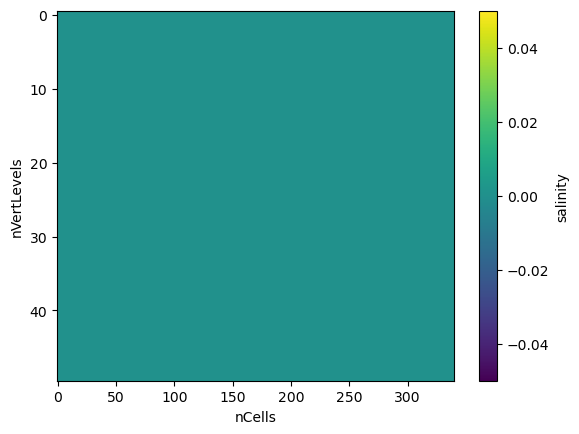

In [7]:
(avg_ds_output.salinity.isel(Time=0) - avg_ds_output.salinity.isel(Time=-1)).plot(y='nVertLevels')
plt.gca().invert_yaxis()

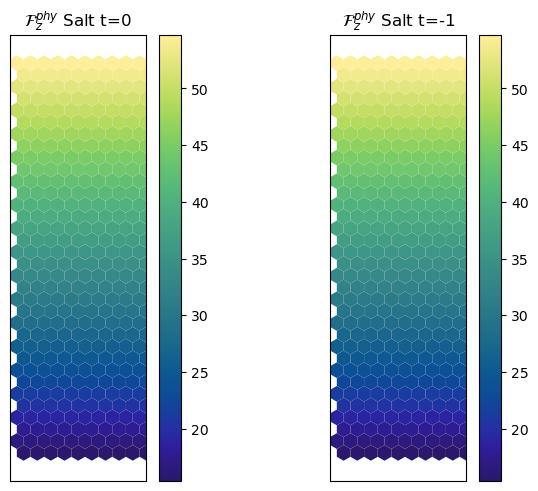

In [8]:
# comparison of mixing
fig,ax = plt.subplots(nrows=1, ncols = 2, constrained_layout=True)

# calculated as convergence of diffusive flux
a = mosaic.polypcolor(ax[0],descriptor, avg_ds_output.salinity.isel(Time=0, nVertLevels=0), cmap='cmo.haline')
b = mosaic.polypcolor(ax[1],descriptor, avg_ds_output.salinity.isel(Time=-1, nVertLevels=0),cmap='cmo.haline')
ax[0].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt t=0')
ax[1].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt t=-1')

for i in range(0,2):
    ax[i].set_aspect(1.0)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

fig.colorbar(a, ax = ax[0])
fig.colorbar(b, ax = ax[1])

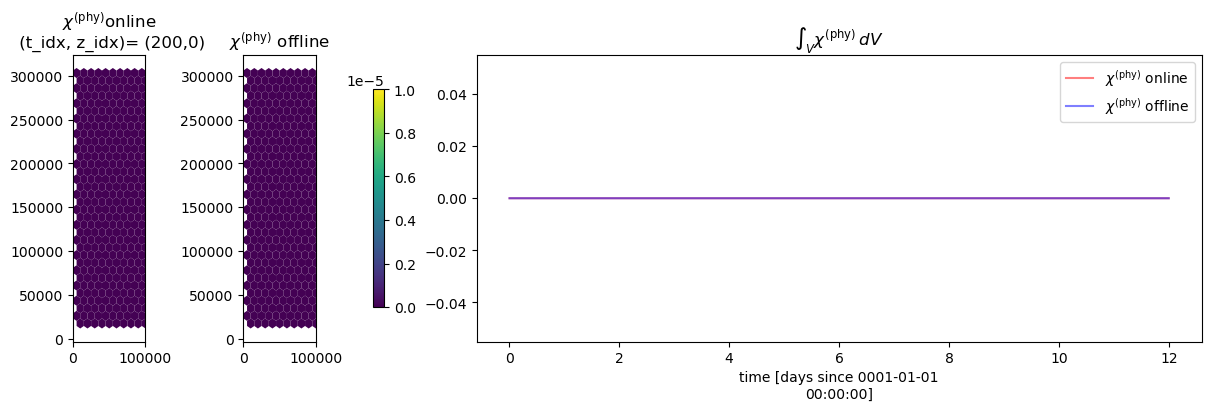

In [9]:
# check chi_phy calculation

s = avg_ds_output.salinity

# we need to use ds, which 1) remaps from cell centers to cell edges and 2) excludes the first and last nVertLevelsP1 coordinates
ds = ds = s[:,:,1:] - s[:,:,:-1]
# rename coordinates to specify cell edges
ds = ds.rename({'nVertLevels' : 'nVertLevelsP1'})
ds = ds.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1.isel(nVertLevelsP1=slice(1,-1))})

# dz already calculates the distance between cell edges. 
# we just need to remap dz onto nVertLevelsP1. 
# since the derivative is nVertLevelsP1_1 - nVertLevelsP1_0, we can exclude the last dz
# the last dz would calcualte ds/dz for nVertLevelsP1_last, which is excluded by the ds array
dz1 = avg_ds_output.layerThickness.isel(nVertLevels=slice(0,-1)).rename({'nVertLevels' : 'nVertLevelsP1'})
dz = dz1.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1.isel(nVertLevelsP1 = slice(1,-1))})

# k_v already sits on nVertLevelsP1
# we exclude the first and last nVertLevelsP1 values, which are not included in the ds or dz array
# note that nVertLevelsP1 = 0 \forall (nCell, Time0) but this is not the case for nVertLevelsP1 = -1
k_v = avg_ds_output.vertDiffTopOfCell.isel(nVertLevelsP1=slice(1,-1)) 

# calculate chi_offline
chi_phy_offline = 2 * k_v * (ds/dz)**2

# trim online chi to be on 49 nVertLevelsP1 for comparison
# this doesn't change the data; chiPhyVerSalt = 0 \forall (nCells,Time) for nVertLevelsP1 = 0 and nVertLevelsP1 = -1
chi_phy_online = avg_ds_output.chiPhyVerSalt.isel(nVertLevelsP1 = slice(1,-1))

# volume integral of chi
dV = mesh.areaCell * dz

chi_phy_offline_Vint = (chi_phy_offline * dV).sum(dim=['nCells','nVertLevelsP1'])
chi_phy_online_Vint = (chi_phy_online * dV).sum(dim=['nCells','nVertLevelsP1'])

fig,ax = plt.subplots(nrows=1, ncols=3, constrained_layout=True, gridspec_kw={'width_ratios' : [1,1,10]}, figsize=(12,4))

time_idx=200
nVP1_idx=0

mosaic.polypcolor(ax[0], descriptor, chi_phy_online.isel(Time=time_idx, nVertLevelsP1 = nVP1_idx),vmin=0, vmax = 1e-5)
ax[0].set_title(r'$\chi^{\text{(phy)}}$' + 'online \n (t_idx, z_idx)= (' + str(time_idx) + ',' + str(nVP1_idx) + ')')
c = mosaic.polypcolor(ax[1], descriptor, chi_phy_offline.isel(Time=time_idx, nVertLevelsP1 = nVP1_idx),vmin=0, vmax = 1e-5)
ax[1].set_title(r'$\chi^{\text{(phy)}}$ offline')

fig.colorbar(c, ax=ax[1])

chi_phy_online_Vint.plot(ax=ax[2],color='red', alpha = 0.5, label = r'$\chi^{\text{(phy)}}$ online')
chi_phy_offline_Vint.plot(ax=ax[2],color='blue', alpha = 0.5, label = r'$\chi^{\text{(phy)}}$ offline')
ax[2].set_title(r'$\int_V \chi^{\text{(phy)}} \, dV$')
ax[2].legend()

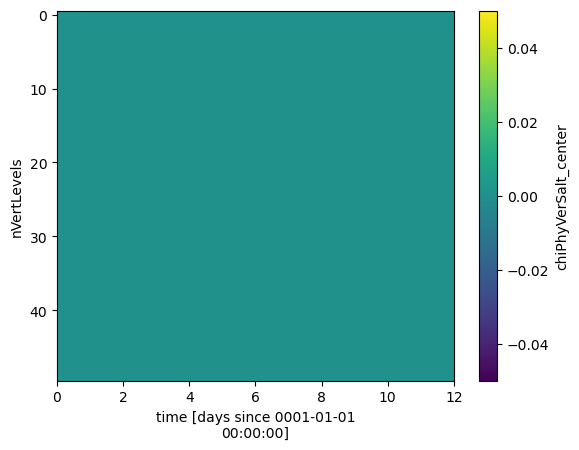

In [10]:
avg_ds_output.chiPhyVerSalt_center.sum(dim='nCells').plot(y='nVertLevels')
plt.gca().invert_yaxis()

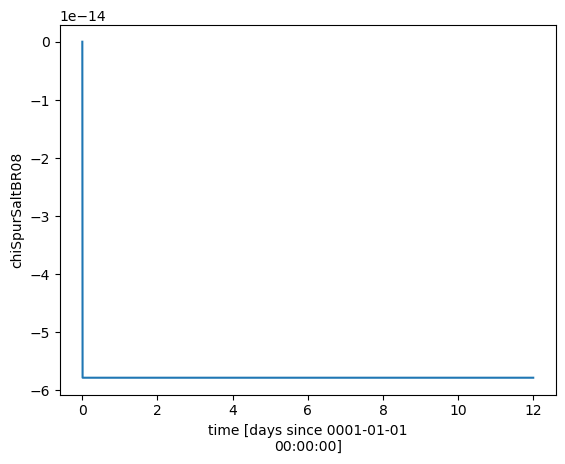

In [11]:
avg_ds_output.chiSpurSaltBR08.sum(dim=['nCells','nVertLevels']).plot()

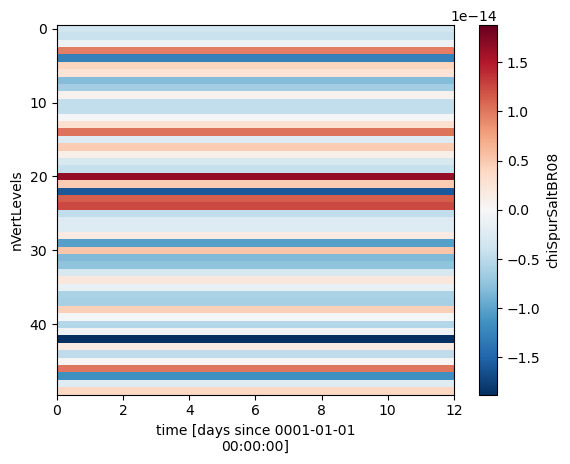

In [12]:
avg_ds_output.chiSpurSaltBR08.sum(dim='nCells').plot(y='nVertLevels')
plt.gca().invert_yaxis()

## Explanation of data

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$ from convergence of a diffusive flux

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} \rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i} - \tilde\lambda_{i+1}}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*Note that we take are looking at $\lambda_i - \lambda_{i+1}$ rather than the other way around. This is because we defined $\mathcal{M}_\ge$ to account for all salinities **greater** than the threshold lambda $\tilde\lambda$. So we are looking from the saltier value to a fresher value (decreasing $\lambda$), rather than a traditional increase.*

*I think this is what also eliminates the negative sign in $\mathcal{G}^{\text{(phy)}}$.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class.

## Calculate $\mathcal{G}_\chi^{\text{(phy)}}$ from tracer variance decay

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = \frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

### Note these are slightly different signs than the earlier equation box. This is because of how we defined $\mathcal{M}_\ge$, which adds a negative sign, since we are interested in how water is being transformed into masses with $\lambda > \tilde\lambda$... I think (6/30/26)

### Non-generalized functions for calculating $\mathcal{G}^\text{(phy)}$

In [13]:
# write function to calculate G_F_phy
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # rho_0 = 1026
    # F_variable = 'salinityVertMixTendency'
    # target_coord_spacing = 1
    
    # calculate the integrand
    dV = (mesh.areaCell * ds_output.layerThickness)
    tendency = rho_0 * ds_output[F_variable] * dV
    
    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels
    
    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'fill', 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
    # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2
    
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # transform integrand onto salinity coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    # rename (should be on salinity coords)
    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})
    
    ds_F_tendency_transformed['salinity_P1'] = target_coords_P1
    
    salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                            padding = 'fill',
                            autoparse_metadata = False)
    
    # reverse cumsum (now sits on salinity_P1)
    da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                                'Z',
                                                                reverse=True)
    
    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    ds_F_volume_int_tendency_transformed['salinity'] = target_coords
    
    # remap back onto salinity coordinates
    ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
                                                                          'Z',
                                                                          padding='fill').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    
    # calculate the derivative of the integrand
    # create array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords)-1):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                         'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    G_F_phy_ds['salinity'] = target_coords[1:-1]
    
    # remap back onto salinity coordinates
    # make a new grid that has the trimmed cordinates
    salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                               padding = 'fill',
                               autoparse_metadata= False)
    
    G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy, 'Z', padding='extend')
    
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])
    
    return G_F_phy_ds

## Note: Is rate of variance decay considered to be a tracer flux? 
It seems to be that the Klingbeil & Hennell 2023 paper seems to treat it as such

In [14]:
# NEW
def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    # rho_0 = 1026
    # target_coord_spacing = 1
    # # your chi_variable should sit on cell centers
    # chi_variable = 'chiPhyVerSalt_center'
    # ds_output = avg_ds_output
    
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print(r'Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print(r'Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * ds_output.layerThickness
    mixing = rho_0 * ds_output[chi_variable] * dV
    
    # set target coordinate bins
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # create a grid to transform mixing from nVertLevels to salinity coords
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
                padding = 'fill',
                autoparse_metadata = False)
    
    # transform
    mixing_salinity = grid.transform(mixing, # currently sitting on cell centers
                                     'Z',
                                     target_coords_P1, # conservative remap requires specifying target edge coords
                                     method = 'conservative',
                                     target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords
    
    # rename coords (still on salinity) and convert to dataset
    mixing_salinity = mixing_salinity.to_dataset(name = 'mixing_per_salinity_cell').rename({'salinity_P1' : 'salinity'})
    
    # add back salinity_P1 coords
    mixing_salinity['salinity_P1'] = target_coords_P1
    
    # sum over each layer to get the mixing per salinity class
    # create a salinity coord grid
    salinity_grid = Grid(mixing_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'fill',
                         autoparse_metadata = False)
    
    # reverse cumsum. remaps from salinity to salinity_P1 coords
    cumulative_mixing = salinity_grid.cumsum(mixing_salinity.mixing_per_salinity_cell,
                                                     'Z',
                                                     reverse=True).to_dataset(name = 'cumulative_' + mixing_type + '_mixing')
    # add back salinity_P1 coords
    cumulative_mixing['salinity_P1'] = target_coords_P1
    
    # interpolate back onto salinity coords, order coords
    cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing['cumulative_' + mixing_type + '_mixing'],
                                                      'Z',
                                                      padding = 'fill').transpose('salinity', 'nCells', 'Time')#.to_dataset(name =  'cumulative_' + mixing_type + '_mixing')
    
    
    # calculate the first derivative (mixing per salinity class) 
    # taking a difference will put values back onto salinity_P1 coords
    mixingPerSalinityClass = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    
    for i in range(0,len(target_coords)-1):
        d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
        mixingPerSalinityClass.append(d_mixing_d_lambda)
    
    # convert mixingPerSalinityClass to dataarray
    mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})
    
    return G_chi_mix_ds

In [15]:
def calculate_dt(avg_ds_output):

    time_format = '%Y-%m-%d_%H:%M:%S'
    t0 = datetime.strptime(avg_ds_output.xtime[0].item().decode(), time_format)
    t1 = datetime.strptime(avg_ds_output.xtime[1].item().decode(), time_format)
    
    dt = (t1 - t0).total_seconds()
    return dt

In [16]:
def calculate_dM_dt(mesh, avg_ds_output, ss_ds_output, target_coord_spacing):
    # calculate dM/dt using new xgcm tools
    # target_coord_spacing = 1
    lower_bound = avg_ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = avg_ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    
    # mass of every grid cell in z coords
    mass = ss_ds_output.density * ss_ds_output.layerThickness * mesh.areaCell
    # then remap into salinity space
    
    mass_transform = ss_ds_grid.transform(mass,
                                          'Z',
                                          target_coords_P1,
                                          method = 'conservative',
                                          target_data = ss_ds_output.salinity_P1)
    
    mass_transform = mass_transform.rename({'salinity_P1' : 'salinity'})
    mass_transform_ds = mass_transform.to_dataset(name='mass_transform')
    mass_transform_ds['salinity_P1'] = target_coords_P1
    mass_transform_ds = mass_transform_ds.set_coords({'salinity_P1' : target_coords_P1})
    
    salinity_grid = Grid(mass_transform_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                        padding = 'fill',
                        autoparse_metadata = False)
    
    # reverse cumsum to accumulate s.t. all mass in the domain is considered when salinity_idx = 0
    
    mass_vint_salinity_P1 = salinity_grid.cumsum(mass_transform_ds.mass_transform, 
                         'Z',
                         reverse='True')
    
    # taking a cumsum moves mass_transform to salinity to salinity_P1 coords
    # interpolate back onto salinity coords
    mass_vint_salinity = salinity_grid.interp(mass_vint_salinity_P1, 'Z', padding = 'fill')
    
    # calculate dM/dt 
    dM = mass_vint_salinity[1:,:,:] - mass_vint_salinity[:-1,:,:]
    dt = calculate_dt(ss_ds_output)
    
    dM_dt = (dM / dt).transpose('salinity', 'nCells', 'Time').to_dataset(name='dM_dt')
    
    return mass, mass_transform, dM_dt

In [17]:
# from xhistogram.xarray import histogram

# def calculate_dM_dt(mesh, avg_ds_output, ss_ds_output, target_coord_spacing):
#     # calculate dM/dt via mass-weighted histogram binning (no monotonicity
#     # assumption -- replaces the xgcm conservative transform, which silently
#     # mis-bins mass in any column where salinity is non-monotonic with depth,
#     # which we've now confirmed is ~100% of columns here)

#     lower_bound = ss_ds_output.salinity_P1.min() - (3 * target_coord_spacing)
#     upper_bound = ss_ds_output.salinity_P1.max() + (3 * target_coord_spacing)
#     target_coords_P1 = np.arange(lower_bound, upper_bound, target_coord_spacing)
#     target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

#     mass = ss_ds_output.density * ss_ds_output.layerThickness * mesh.areaCell

#     # NOTE: mass lives on layer *centers*, so it must be binned by
#     # layer-center salinity, not interface (P1) salinity. If ss_ds_output
#     # doesn't carry cell-center salinity directly, average the interfaces
#     # bounding each layer instead.
#     if 'salinity' in ss_ds_output:
#         salinity_center = ss_ds_output.salinity
#     else:
#         s_p1 = ss_ds_output.salinity_P1
#         salinity_center = 0.5 * (
#             s_p1.isel(nVertLevelsP1=slice(None, -1)).values
#             + s_p1.isel(nVertLevelsP1=slice(1, None)).values
#         )
#         salinity_center = xr.DataArray(
#             salinity_center, dims=mass.dims, coords=mass.coords
#         )

#     # mass-weighted histogram: sums mass into salinity bins, summing over the
#     # vertical dimension only, independently per nCells/Time -- no
#     # monotonicity requirement, and conserves mass exactly by construction
#     # (every layer's mass is counted in exactly one bin)
#     mass_transform = histogram(
#         salinity_center.rename('salinity'),
#         bins=[target_coords_P1],
#         dim=['nVertLevels'],
#         weights=mass,
#     )

#     bin_dim = [d for d in mass_transform.dims if d.startswith('salinity')][0]
#     mass_transform = mass_transform.rename({bin_dim: 'salinity'})
#     mass_transform = mass_transform.assign_coords(salinity=target_coords)

#     # reverse cumsum along salinity so that at salinity_idx = 0, all mass in
#     # the domain (down to the lowest bin) is accumulated -- same convention
#     # as before, but now directly on bin centers since histogram output is
#     # already on centers (no P1<->center interpolation step needed)
#     mass_vint_salinity = (
#         mass_transform.isel(salinity=slice(None, None, -1))
#         .cumsum('salinity')
#         .isel(salinity=slice(None, None, -1))
#     )

#     # calculate dM/dt -- label-based Time indexing, not positional slicing
#     dM = (
#         mass_vint_salinity.isel(Time=slice(1, None)).values
#         - mass_vint_salinity.isel(Time=slice(None, -1)).values
#     )
#     dM = xr.DataArray(
#         dM,
#         dims=mass_vint_salinity.dims,
#         coords={
#             d: (
#                 mass_vint_salinity[d].isel(Time=slice(1, None))
#                 if d == 'Time'
#                 else mass_vint_salinity[d]
#             )
#             for d in mass_vint_salinity.dims
#         },
#     )

#     dt = calculate_dt(ss_ds_output)

#     dM_dt = (dM / dt).transpose('salinity', 'nCells', 'Time').to_dataset(name='dM_dt')

#     return mass, mass_transform, dM_dt

In [18]:
def calculate_G_F_num(dM_dt, G_F_phy_ds):
    G_F_num = (dM_dt.dM_dt - G_F_phy_ds.G_F_phy_center).transpose('salinity','nCells','Time')
    G_F_num_ds = G_F_num.to_dataset(name = 'G_F_num')
    return G_F_num_ds

In [19]:
# wrapper function to perform all calculations
def calculate_budget(rho_0, mesh, ds_output, target_coord_spacing = 1):
    print('Calculating G_F_phy')
    G_F_phy_ds = calculate_G_F_phy('salinityVertMixTendency', rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, avg_ds_output,target_coord_spacing)

    print('Calculating dM/dt')
    mass, mass_transform, dM_dt_ds = calculate_dM_dt(mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
    
    print('Calculating G_F_num')
    G_F_num_ds = calculate_G_F_num(dM_dt_ds, G_F_phy_ds)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    budget_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              dM_dt_ds,
                              G_F_num_ds,
                              avg_ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds

In [20]:
# volume integrate G_mix terms, which should = 0
def lambda_integrate_G_mix(variable, target_coord_spacing):
    
    integrated = (budget_ds[variable] * target_coord_spacing).sum().values
    
    print('lambda_integrated ' + variable + '= %.2E' % integrated )
    return integrated

In [21]:
# calculate transformation at every density class
def vertical_cumsum(G_phy_ds, variable, reduce_time_dim_method, time_idx=0):

    if reduce_time_dim_method == 'average':
        G_phy = G_phy_ds[variable].mean(dim='Time').sum(dim='nCells')

    if reduce_time_dim_method == 'isel':
        G_phy = G_phy_ds[variable].isel(Time = time_idx).sum(dim='nCells')
        
    # cumsum from bottom (lowest salinity class) to top (highest salinity class)
    # we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
    # reduce G_phy_ds along several dimensions
    
    rev_G_phy = np.flipud(G_phy)
    cumsum_rev_G_phy = np.cumsum(rev_G_phy)
    # reverse back to match highest salinity value to lowest cumsum value
    cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

    print('reduced time dimension by ', reduce_time_dim_method)
    if reduce_time_dim_method == 'isel':
        print('time_idx = ', time_idx)

    return G_phy, cumsum_G_phy

In [22]:
## figure out at what salinity are the minima and maxima located for G_F_phy and G_chi_phy

def find_min_max_idx(da):
    # max if G_i > G_i+1 and G_i > G_i-1
    maxima_indices = np.where((da[1:-1] > da[:-2]) & (da[1:-1] > da[2:]))[0] + 1
    print('maxima at ', da[maxima_indices])
    
    # min if G_i < G_i+1 and G_i < Gi-1
    minima_indices = np.where((da[1:-1] < da[:-2]) & (da[1:-1] < da[2:]))[0] + 1
    print('minima at ' , da[minima_indices])

    return maxima_indices, minima_indices

-------
--------

In [23]:
# initialize lambda-integrated matrix
rho_0 = 1026
dlambda_matrix = []

for target_coord_spacing_choice in np.array([0.25, 0.5, 1, 2,3,10]):
    print(f'dlambda = {target_coord_spacing_choice}')
    # initialize matrix for each dlambda choice
    dlambda_array = np.array([])
    G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds = calculate_budget(rho_0, mesh, avg_ds_output, target_coord_spacing_choice)
    for variable in ['G_F_phy','G_F_num','G_chi_phy','G_chi_num','dM_dt']:
        lambda_integrated_G_mix_var = lambda_integrate_G_mix(variable, target_coord_spacing_choice)
        dlambda_array = np.append(dlambda_array, lambda_integrated_G_mix_var)
        
    dlambda_matrix.append(dlambda_array)

dlambda_matrix_final = np.vstack(dlambda_matrix)

dlambda = 0.25
Calculating G_F_phy
Calculating G_chi_phy
Calculating G_chi_num
Calculating dM/dt
Calculating G_F_num
lambda_integrated G_F_phy= 0.00E+00
lambda_integrated G_F_num= 0.00E+00
lambda_integrated G_chi_phy= 0.00E+00
lambda_integrated G_chi_num= -2.44E-15
lambda_integrated dM_dt= 0.00E+00
dlambda = 0.5
Calculating G_F_phy
Calculating G_chi_phy
Calculating G_chi_num
Calculating dM/dt
Calculating G_F_num
lambda_integrated G_F_phy= 0.00E+00
lambda_integrated G_F_num= 0.00E+00
lambda_integrated G_chi_phy= 0.00E+00
lambda_integrated G_chi_num= -3.00E-15
lambda_integrated dM_dt= 0.00E+00
dlambda = 1.0
Calculating G_F_phy
Calculating G_chi_phy
Calculating G_chi_num
Calculating dM/dt
Calculating G_F_num
lambda_integrated G_F_phy= 0.00E+00
lambda_integrated G_F_num= 0.00E+00
lambda_integrated G_chi_phy= 0.00E+00
lambda_integrated G_chi_num= 5.41E-16
lambda_integrated dM_dt= 0.00E+00
dlambda = 2.0
Calculating G_F_phy
Calculating G_chi_phy
Calculating G_chi_num
Calculating dM/dt
Calcula

In [24]:
target_coord_spacing_array = np.array([0.25, 0.5, 1, 2, 3, 10])
lambda_int_G_F_phy = dlambda_matrix_final[:,0]
lambda_int_G_F_num = dlambda_matrix_final[:,1]
lambda_int_G_chi_phy = dlambda_matrix_final[:,2]
lambda_int_G_chi_num = dlambda_matrix_final[:,3]
lambda_int_dM_dt = dlambda_matrix_final[:,4]

Text(0, 0.5, '$[kg \\times \\lambda /s]$')

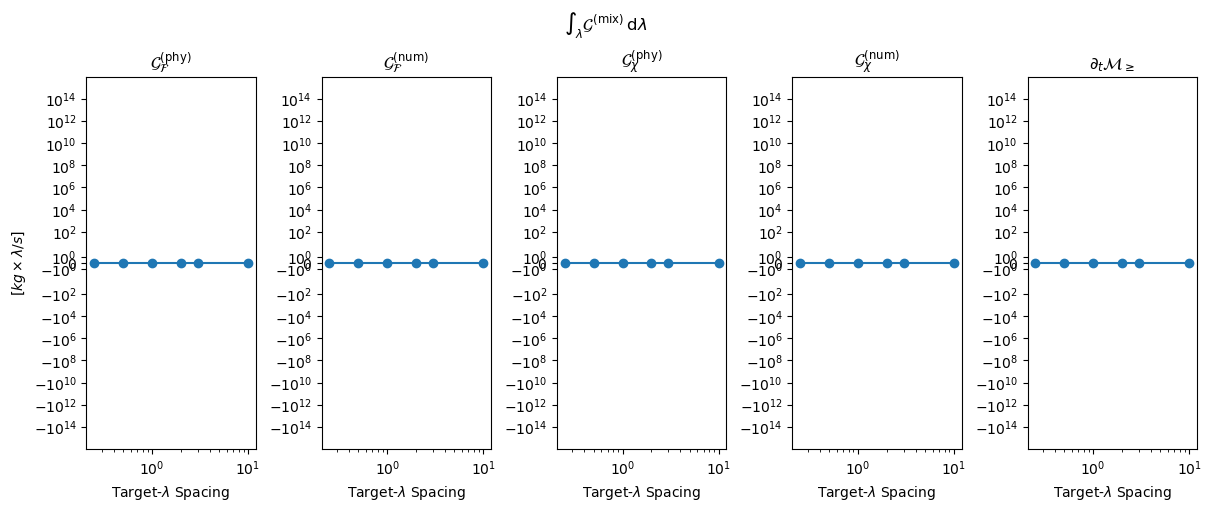

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=5, constrained_layout=True, figsize = (12,5))
titles = [r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$', r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$', r'$\mathcal{G}_\chi^{\text{(phy)}}$', r'$\mathcal{G}_\chi^{\text{(num)}}$', r'$\partial_t \mathcal{M}_\geq$']

for i in range(0,5):
    ax[i].plot(target_coord_spacing_array, dlambda_matrix_final[:,i], marker='o')
    ax[i].set_title(titles[i])
    ax[i].set_xscale('log')
    ax[i].set_yscale('symlog')
    ax[i].set_xlabel(r'Target-$\lambda$ Spacing')
    ax[i].set_ylim(-10e15, 10e15)

fig.suptitle(r'$\int_\lambda \mathcal{G}^{\text{(mix)}} \, \text{d}\lambda$')
ax[0].set_ylabel(r'$[kg \times \lambda /s]$')


In [26]:
dlambda_matrix_final

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.44249065e-15,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.99760217e-15,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         5.41233725e-16,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.22044605e-16,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.77555756e-17,  0.00000000e+00]])

### Analysis
The $\lambda$-integrated budget terms plotted above are suggesting to me that we are not accounting for some type of process, perhaps?
>- I reccognize that there are some places in the code that can be tweaked (e.g., interpolating back to center coords after taking a cumulative sum, time-average interval could be smaller, target coordinate choicce could be more intentional)
>- However, the discrepancies betweeen the $\partial_t \mathcal{M}_\geq$ calculation and the $\mathcal{G}^{\text{(mix)}}$ calculation are so large ($\mathcal{O}(10^8)$) that I just don't think these smaller errors are that significant?

Here is why I am confused.
>- If we assume the only terms in the budget are the diascalar material transformation due to mixing $\mathcal{G}^{\text{(mix)}}$, then the budget is

$$
\begin{align}
    \partial_t \mathcal{M}_\geq &= \mathcal{G}_\chi^{\text{(phy)}} + \mathcal{G}_\chi^{\text{(phy)}} \\
    \implies \int_{\max \lambda}^{\min \lambda} \partial_t \mathcal{M}_\geq \, \text{d}\lambda &= \int_{\max \lambda}^{\min \lambda} \mathcal{G}_\chi^{\text{(phy)}} \, \text{d}\lambda+ \int_{\max \lambda}^{\min \lambda} \mathcal{G}_\chi^{\text{(phy)}} \, \text{d}\lambda
\end{align}
$$

>- However, the above plots show that \int_\lambda $\mathcal{G}_\chi^{\text{(phy)}} \, \text{d}\lambda= \int_\lambda \mathcal{G}_\chi^{\text{(phy)}} \, \text{d}\lambda= 0 \neq \int_\lambda \partial_t \mathcal{M}_\geq \, \text{d}\lambda$ for all $\Delta \lambda$ spacings that we choose.
>- This suggests there is some other term in the budget that is changing the $\mathcal{M}_\geq$ that is not accounted for.
>- At first I thought it was the vertical and/or horizontal advection that was somehow causing a transformation (although we let the region $\mathcal{R}$ be the full domain, so I don't think this is possible).
>- However, we then ran these simulations with the advection disabled, and `salinityVerticalAdvectionTendency` and `salinityHorizontalAdvectionTendency` = 0 for every grid cell for every timestep.
>- This means these terms do not make up for the uknown residual currently in this budget.

>- Running without advection also provided insight to another potential problem, which is that, even without advection, the DVD scheme still calculates some amount of numerical mixing.
>- For an individual grid scale, the $\mathcal{G}_\chi^{\text{(num)}}$  value is $\mathcal{O}(10^{-17} - 10^{-16}\, kg/s)$ when remapped to coordinates with $\Delta \lambda = 0.25$.
>- While this seems insignficantly small (and the value $\chi^{\text{(num)}}$ is calculated at double-precision), the *sum* of $\mathcal{G}_\chi^{\text{(num)}}$ over the entire isosurface is $\mathcal{O}(10^{-1}\, kg/s)$.
>- While this value is still small relative to $\mathcal{G}_\chi^{\text{(phy)}}$ of $\mathcal{O}(10^{6}\, kg/s)$, this error is not negligible, particularly when the sum of $\mathcal{G}^{\text{(num)}}$ over an isosurface should be exactly 0 when there is no advection.
>- These existing errors could compound when advection is turned on or when resolution is refined.  

In [30]:
rho_0 = 1026
target_coord_spacing = 0.25

mass, mass_transform, dM_dt = calculate_dM_dt(mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds = calculate_budget(rho_0, mesh, avg_ds_output, target_coord_spacing)

Calculating G_F_phy
Calculating G_chi_phy
Calculating G_chi_num
Calculating dM/dt
Calculating G_F_num


In [36]:
dM_native = mass[1:,:,:] - mass[:-1,:,:]
dM_dt_native = dM_native / calculate_dt(ss_ds_output)

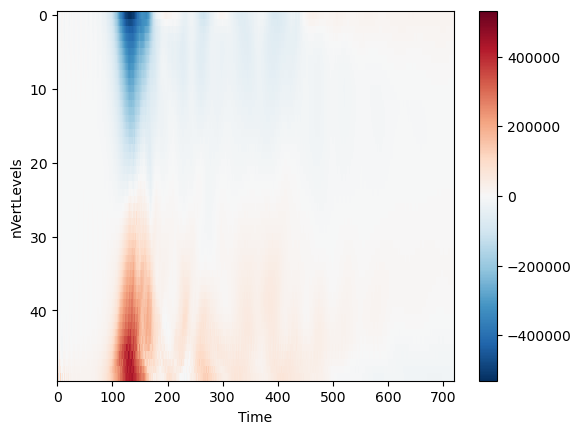

In [37]:
dM_dt_native.sum(dim='nCells').plot(y='nVertLevels')
plt.gca().invert_yaxis()

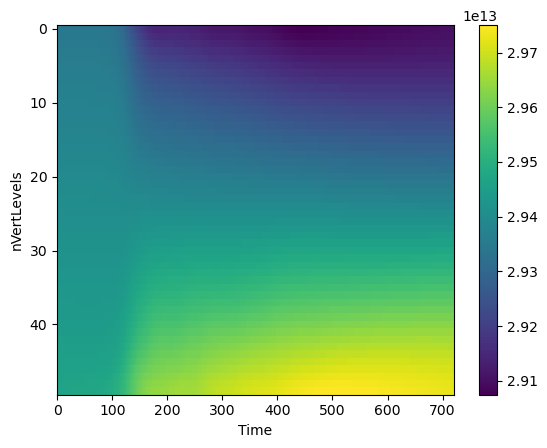

In [38]:
mass.sum(dim='nCells').plot(y='nVertLevels')
plt.gca().invert_yaxis()

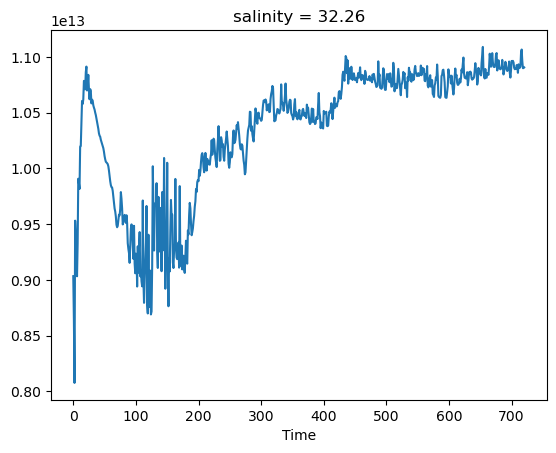

In [39]:
mass_transform.sum(dim='nCells').isel(salinity=70).plot()

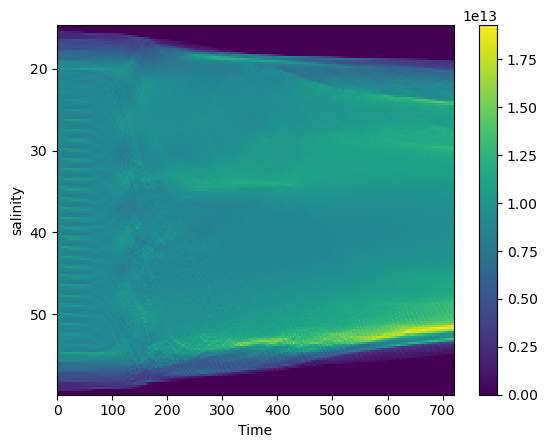

In [40]:
mass_transform.sum(dim='nCells').plot(y='salinity')
plt.gca().invert_yaxis()

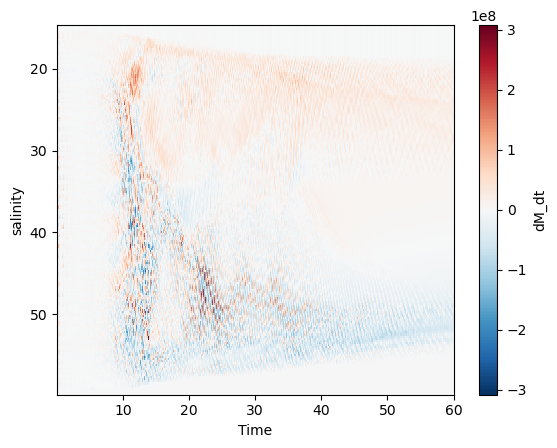

In [41]:
budget_ds.dM_dt.sum(dim='nCells').plot(y='salinity')
plt.gca().invert_yaxis()

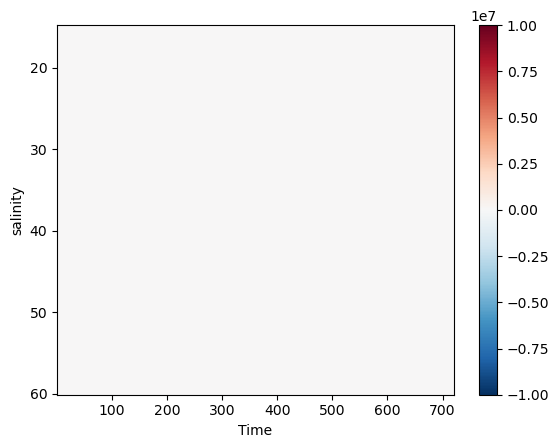

In [83]:
(budget_ds.dM_dt - (budget_ds.G_chi_phy + budget_ds.G_chi_num)).sum(dim='nCells').plot(y='salinity',vmin=-1e7, vmax=1e7, cmap='RdBu_r')
plt.gca().invert_yaxis()

In [84]:
G_F_vadv_phy_ds = calculate_G_F_phy('salinityVerticalAdvectionTendency', rho_0, mesh, avg_ds_output,target_coord_spacing)
G_F_hadv_phy_ds = calculate_G_F_phy('salinityHorizontalAdvectionTendency', rho_0, mesh, avg_ds_output,target_coord_spacing)

As the bin size increases, generally, the $\mathcal{G}^{\text{(mix)}}$ term converges, but not necessarily to a value of 0, which is what we would expect. Not sure why this is, going to look at this paper: [Numerical issues of the Total Exchange Flow (TEF) analysis framework for quantifying estuarine circulation](https://os.copernicus.org/articles/15/601/2019/). 

## How do we know if there is reasonable convergence of $\mathcal{G}^{\text{(mix)}}$ variables?
>- An unofficial consensus amongst the numerical mixing community is that discrete variance decay algorithms disagree locally but agree in the global calculation.
>- So we would want to volume-integrate over the full domain to check if this is true with our two metrics.
>- We can do this in two ways, bearing in mind that we integrate from saltiest to freshest water (since $\mathcal{M} = \mathcal{M}_\geq$).

1. Direct calcuation from $\mathcal{G}^{\text{(mix)}}$.
$$
\begin{align}
    \int_{\max \lambda}^{\min \lambda} \mathcal{G}^{\text{(mix)}} \, \text{d}\lambda \simeq \sum_{i=\max bin}^{0} \mathcal{G}^{\text{(mix)}} \, \Delta \lambda
\end{align}
$$

2. Calcualate from salinity flux tendency and apply the Fundamental Theorem of Calculus.

$$
\begin{align}
    \int_{\max \lambda}^{\min \lambda} \mathcal{G}^{\text{(mix)}} \, \text{d}\lambda &= \int_{\max \lambda}^{\min \lambda} \partial_\lambda \int_{\Omega(\tilde\lambda,t)} \rho \mathcal{F} \, \text{d} V \, \text{d}\lambda \\
   &= \int_{\max \lambda}^{\min \lambda} \partial_\lambda G^{\text{(mix)}} \, \text{d} \lambda \\
   \int_{\max \lambda}^{\min \lambda} \mathcal{G}^{\text{(mix)}} \, \text{d}\lambda &= G^{\text{(mix)}}(\min \lambda) -  G^{\text{(mix)}}(\max \lambda)
\end{align}
$$

We can then check our work by comaparing the results of the two methods.

3. One question we can ask is if we would expect the $\lambda$-integrated $\mathcal{G}^{\text{(mix)}}$ terms to equal zero. The physical meaning of the $\lambda$-integrated mixing process is difficult for me to conceptualize. Intuitively, we may think that $\lambda$-integrated terms should = 0. I'll explain why below.

>- Apply the divergence theorem since $\mathcal{F}$ is the convergence of a flux: $\mathcal{F} = - \nabla \cdot \left( -\kappa_v \nabla \lambda \right)$.
>- Recall that $\mathcal{R}$ is the surface of the region defining $\mathcal{M}$ (the boundary of the volume $\Omega(\tilde\lambda, t)$)
>- However, since we do not define a geographic region for this idealized channel case, the only boundary for the volume $\Omega(\tilde\lambda, t)$ is the isosurface where $\lambda = \tilde\lambda$, denoted as $\mathcal{A_R}$.

$$
\begin{align}
    \int_{\max \lambda}^{\min \lambda} \mathcal{G}^{\text{(mix)}} \, \text{d}\lambda &= \int_{\max \lambda}^{\min \lambda} \partial_\lambda \int_{\Omega(\tilde\lambda,t)} \rho \mathcal{F} \, \text{d} V \, \text{d}\lambda \\
   &= \int_{\max \lambda}^{\min \lambda} \partial_\lambda \underbrace{\int_{\mathcal{A_R}} \rho \left(-\kappa_v \nabla \lambda\right) \cdot \mathbf{\hat{n}} \, \text{d}S \,}_{G^{\text{(mix)}}} \text{d}\lambda
\end{align}
$$

>- We are calculating $G^{\text{(mix)}}$ at every $\tilde\lambda$ surface.
>- Note that $G^{\text{(mix)}}(\lambda = \max \lambda) = G^{\text{(mix)}}(\lambda = \min\lambda) = 0 $ because $\mathbf{\hat{n}} = 0$
> >No-flux conditions at the surface and bottom of the domain; fresh water cannot get any fresher and salty water can't get any saltier.
> >
> >This isn't technically not a "boundary" condition, which is set by geography and not tracer concentration, but it holds since $\mathbf{\hat n} =0$ (how is the gradient supposed to point in the driection of greatest increase if there is no increase in $\lambda$)
> >
> >This would also mean that, by method #2, the $\lambda$-integrated $\mathcal{G}^{\text{(mix)}}$ term must equal zero. 
>- If you are not convinced by thinking about method #2, consider what taking the derivative of $G^{\text{(mix)}}$ wrt $\lambda$ means.
>- Let $i$ represent the $\tilde \lambda$ surface such that low values of $i$ signify fresh water and high values of $i$ signify salty water.

$$
\begin{equation}
    \frac{\partial}{\partial \lambda} \left[ G^{\text{(mix)}} \right] \simeq \frac{G_i^{\text{(mix)}} - G_{i+1}^{\text{(mix)}}}{\lambda_i - \lambda_{i+1}} = \mathcal{G}^{\text{(mix)}}
\end{equation}
$$

>- However, we want the *integral* of $\mathcal{G}^{\text{(mix)}}$ wrt $\lambda$. Discretely, that means taking the sum over all $\tilde \lambda$ surfaces weighted by $\Delta \lambda$.

$$
\begin{align}
    \int_{\max \lambda}^{\min \lambda} \mathcal{G}^{\text{(mix)}} \, \text{d}\lambda  = \sum_{\max i}^{\max bins} \partial_\lambda G^{\text{(mix)}} \Delta \lambda &= \frac{1}{\Delta \lambda} \left( G^{\text{(mix)}}_i -G^{\text{(mix)}}_{\max \lambda} +  G^{\text{(mix)}}_{i-1} -G^{\text{(mix)}}_{i} + G^{\text{(mix)}}_{i-2} -G^{\text{(mix)}}_{i-1} +  G^{\text{(mix)}}_{\min \lambda} -G^{\text{(mix)}}_{i-2} \right) \\
    \sum_{\max i}^{\max bins} \partial_\lambda G^{\text{(mix)}} \Delta \lambda &= G^{\text{(mix)}}_{\min \lambda} - G^{\text{(mix)}}_{\max \lambda} \\
    \int_{\max \lambda}^{\min \lambda} \mathcal{G}^{\text{(mix)}} \, \text{d}\lambda  &= 0-0 = 0
\end{align}
$$

>- Notice that the terms cancel, and we are left with just $G^{\text{(mix)}}$ at the surface and bottom of the domain where there are no-flux boundary conditions.


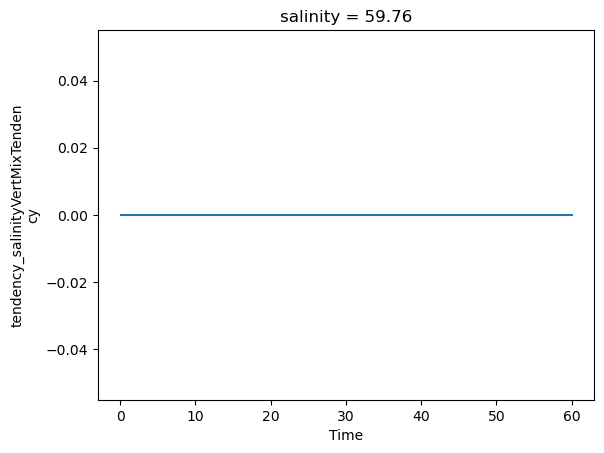

In [85]:
G_F_phy_ds.tendency_salinityVertMixTendency.isel(salinity=-1).sum(dim='nCells').plot()

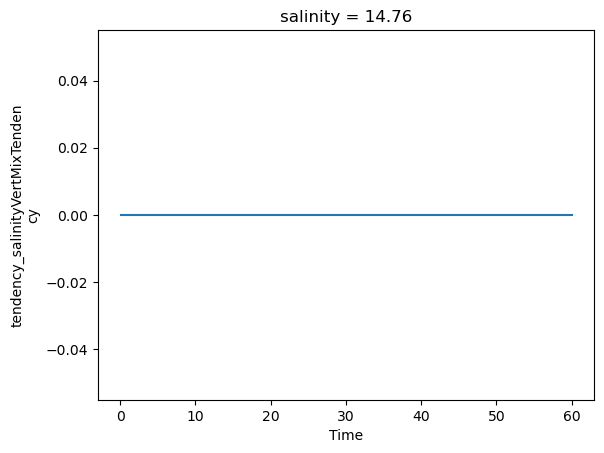

In [86]:
G_F_phy_ds.tendency_salinityVertMixTendency.isel(salinity=0).sum(dim='nCells').plot()

In [87]:
G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, avg_ds_output,target_coord_spacing)
    
G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, avg_ds_output,target_coord_spacing)

Calculating G_chi_phy
Calculating G_chi_num


Text(0, 0.5, 'Number of cells')

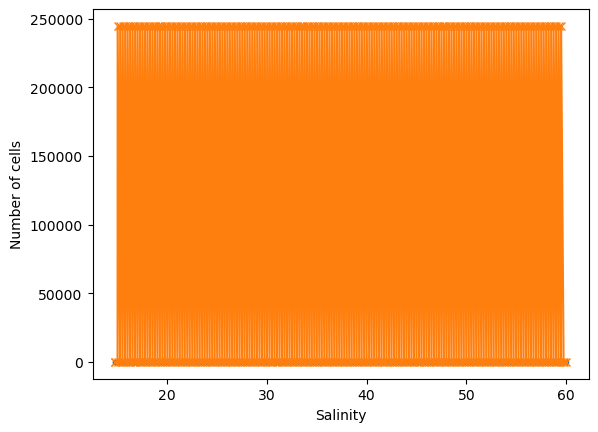

In [88]:
budget_ds.G_F_num.notnull().sum(dim=["Time", "nCells"]).plot(marker = '.')
budget_ds.G_chi_num.notnull().sum(dim=["Time", "nCells"]).plot(marker = 'x')

plt.xlabel("Salinity")
plt.ylabel("Number of cells")

ValueError: x and y must have same first dimension, but have shapes (363,) and (182,)

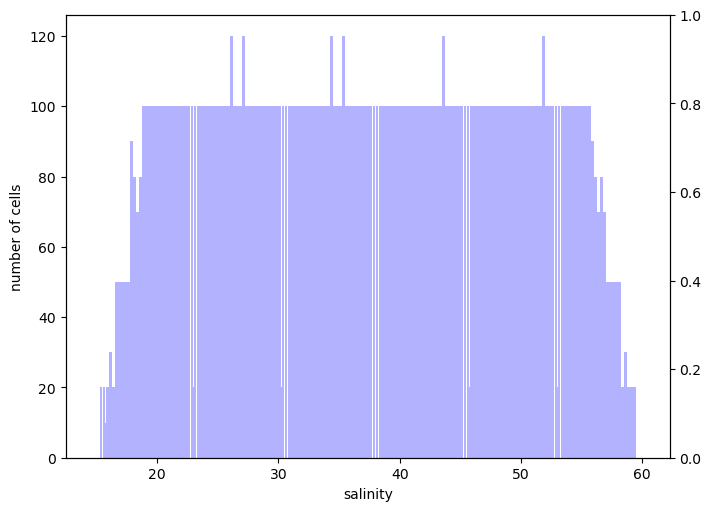

In [89]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, constrained_layout=True, figsize=(7,5))
target_coords = budget_ds.salinity

mesh.salinity.plot.hist(ax=ax1, bins=target_coords,alpha=0.3, color='blue', label ='cell count');
ax1.set_ylabel('number of cells')

ax2 = ax1.twinx()

bin_centers = 0.5 * (target_coords[:-1] + target_coords[1:])
ax2.plot(target_coords, mass_transform.sum('nCells').isel(Time=0), color='black', linewidth=3, marker='o', label = 'mass')

ax2.set_ylim(0,5e13)
ax2.set_ylabel('Total mass in salinity bin [kg]')
fig.suptitle(r'Init file; $\Delta s =$'+ str(target_coord_spacing))
fig.legend()

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=2, constrained_layout=True,figsize=(15,5))
mass.sum(dim='nCells').plot(ax=ax[0], y='nVertLevels',cmap=cmo.gray)
c = ss_ds_output.salinity.mean(dim='nCells').plot.contour(ax=ax[0], levels = target_coords[10:-10], y = 'nVertLevels', cmap = cmo.matter)
ax[0].invert_yaxis()
fig.colorbar(c, ax =ax[0])
ax[0].clabel(c)
ax[0].set_title('Mass and salinity nVertLevel over time')

ke_transform = avg_ds_grid.transform(avg_ds_output.kineticEnergyCell,
                                     'Z',
                                     target_coords,
                                     method = 'linear',
                                     target_data = avg_ds_output.salinity)

ke_transform.sum('nCells').plot(ax=ax[1],y='salinity',cmap='cmo.speed')
# avg_ds_output.kineticEnergyCell.sum('nCells').plot(y='nVertLevels')
ax[1].invert_yaxis()
ax[1].set_title('Kinetic energy over time')

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=5, constrained_layout=True, figsize=(20,5))
mass.sum(dim='nCells').plot(ax=ax[0], y='nVertLevels', add_colorbar=False)
ax[0].set_title('Total mass per nVertLevels')

mass_transform.sum(dim='nCells').plot(ax=ax[1], y='salinity')
ax[1].set_title('Total mass per salinity level')

(mass / mass).sum(dim='nCells').plot(ax=ax[2], y='nVertLevels', add_colorbar=False, cmap='Purples')
ax[2].set_title('Total cells per nVertLevel')

(mass_transform / mass_transform).sum(dim='nCells').plot(ax=ax[3], y='salinity', cmap='Purples')
ax[3].set_title('Total cells per salinity level')

mass.sum(dim=['nCells','nVertLevels']).plot(ax=ax[4], label='native', alpha=0.5, color='gray',marker='x')
mass_transform.sum(dim=['nCells','salinity']).plot(ax=ax[4], label='salinity', alpha=0.5, color='orange',marker='.')
ax[4].set_title('total Mass over time')
ax[4].set_ylabel('Mass [kg]')
ax[4].legend()

for i in range(0,5):
    ax[i].invert_yaxis()

In [ ]:
fig, ax = plt.subplots(nrows=3,ncols=2,constrained_layout=True,figsize=(12,9))

budget_ds.G_chi_phy.sum(dim='nCells').plot(ax=ax[0,0],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[0,0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
budget_ds.G_chi_num.sum(dim='nCells').plot(ax=ax[0,1],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[0,1].set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')

budget_ds.G_F_phy_center.sum(dim='nCells').plot(ax=ax[1,0],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[1,0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
budget_ds.G_F_num.sum(dim='nCells').plot(ax=ax[1,1],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[1,1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

c = budget_ds.dM_dt.sum(dim='nCells').plot(ax=ax[2,0], y='salinity', vmin=-1e8, vmax=1e8, cmap ='RdBu_r',add_colorbar=False)
ax[2,0].set_title(r'$\partial_t \mathcal{M}_\geq$')

d = mass_transform.sum(dim='nCells').plot(ax=ax[2,1], y='salinity', add_colorbar=False)
ax[2,1].set_title(r'$\mathcal{M}$ at each salinity surface')

fig.colorbar(c, ax=ax, label='WMT rate [kg/s]')
fig.colorbar(d, ax=ax[2,1],location='bottom', label = 'Mass [kg]')
             
for i in range(0,3):
    for j in range(0,2):
        ax[i,j].invert_yaxis()

fig.suptitle('Total budget term along isohaline surfaces over time')

In [ ]:
fig, ax = plt.subplots(nrows=3,ncols=2,constrained_layout=True,figsize=(12,9))

budget_ds.G_chi_phy.sum(dim='nCells').plot(ax=ax[0,0],y='salinity', cmap='RdBu_r', add_colorbar=True)
ax[0,0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
budget_ds.G_chi_num.sum(dim='nCells').plot(ax=ax[0,1],y='salinity', cmap='RdBu_r', add_colorbar=True)
ax[0,1].set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')

budget_ds.G_F_phy_center.sum(dim='nCells').plot(ax=ax[1,0],y='salinity', cmap='RdBu_r', add_colorbar=True)
ax[1,0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
budget_ds.G_F_num.sum(dim='nCells').plot(ax=ax[1,1],y='salinity', cmap='cmo.haline', add_colorbar=True)
ax[1,1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

c = budget_ds.dM_dt.sum(dim='nCells').plot(ax=ax[2,0], y='salinity', cmap ='cmo.haline',add_colorbar=True)
ax[2,0].set_title(r'$\partial_t \mathcal{M}_\geq$')

d = mass_transform.sum(dim='nCells').plot(ax=ax[2,1], y='salinity', add_colorbar=True, cmap='cmo.haline')
ax[2,1].set_title(r'$\mathcal{M}$ at each salinity surface')

# fig.colorbar(c, ax=ax, label='WMT rate [kg/s]')
# fig.colorbar(d, ax=ax[2,1],location='bottom', label = 'Mass [kg]')
             
for i in range(0,3):
    for j in range(0,2):
        ax[i,j].invert_yaxis()

fig.suptitle('Total budget term along isohaline surfaces over time')

In [ ]:
fig, ax = plt.subplots(nrows=4,ncols=2,constrained_layout=True,figsize=(12,9))

budget_ds.G_chi_phy.sum(dim='nCells').plot(ax=ax[0,0],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[0,0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
budget_ds.G_chi_num.sum(dim='nCells').plot(ax=ax[0,1],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[0,1].set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')

budget_ds.G_F_phy_center.sum(dim='nCells').plot(ax=ax[1,0],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[1,0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
budget_ds.G_F_num.sum(dim='nCells').plot(ax=ax[1,1],y='salinity',vmin=-1e8, vmax=1e8, cmap='RdBu_r', add_colorbar=False)
ax[1,1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

c = budget_ds.dM_dt.sum(dim='nCells').plot(ax=ax[2,0], y='salinity', vmin=-1e8, vmax=1e8, cmap ='RdBu_r',add_colorbar=False)
ax[2,0].set_title(r'$\partial_t \mathcal{M}_\geq$')

d = mass_transform.sum(dim='nCells').plot(ax=ax[2,1], y='salinity', add_colorbar=False)
ax[2,1].set_title(r'$\mathcal{M}$ at each salinity surface')

G_F_vadv_phy_ds.G_F_phy_center.sum(dim='nCells').plot(ax=ax[3,0], y='salinity', vmin=-1e8, vmax=1e8, cmap ='cmo.haline', add_colorbar=False)
ax[3,0].set_title(r'$\mathcal{G}_{\mathcal{F}_{z adv}}$')

G_F_hadv_phy_ds.G_F_phy_center.sum(dim='nCells').plot(ax=ax[3,1], y='salinity', vmin=-1e8, vmax=1e8, cmap ='cmo.haline', add_colorbar=False)
ax[3,1].set_title(r'$\mathcal{G}_{\mathcal{F}_{x adv}}$')

fig.colorbar(c, ax=ax, label='WMT rate [kg/s]')
             
for i in range(0,3):
    for j in range(0,2):
        ax[i,j].invert_yaxis()

fig.suptitle('Total budget term along isohaline surfaces over time')

In [ ]:
avg_ds_output.chiPhyVerSalt_center.sum(dim='nCells').plot(y='nVertLevels')
plt.gca().invert_yaxis()

In [ ]:
resid = budget_ds.dM_dt - budget_ds.G_chi_phy - budget_ds.G_F_phy_center

In [ ]:
fig, ax = plt.subplots(nrows=3,ncols=2,constrained_layout=True,figsize=(12,9))

budget_ds.G_chi_phy.mean(dim='nCells').plot(ax=ax[0,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[0,0].set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
budget_ds.G_chi_num.mean(dim='nCells').plot(ax=ax[0,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[0,1].set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')

budget_ds.G_F_phy_center.mean(dim='nCells').plot(ax=ax[1,0],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[1,0].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
budget_ds.G_F_num.mean(dim='nCells').plot(ax=ax[1,1],y='salinity',vmin=-1e6, vmax=1e6, cmap='RdBu_r', add_colorbar=False)
ax[1,1].set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

c = budget_ds.dM_dt.mean(dim='nCells').plot(ax=ax[2,0], y='salinity', vmin=-1e6, vmax=1e6, cmap ='RdBu_r',add_colorbar=False)
ax[2,0].set_title(r'$\partial_t \mathcal{M}_\geq$')

d = mass_transform.sum(dim='nCells').plot(ax=ax[2,1], y='salinity', add_colorbar=False)
ax[2,1].set_title(r'$\mathcal{M}$ at each salinity surface')

fig.colorbar(c, ax=ax, label='WMT rate [kg/s]')
fig.colorbar(d, ax=ax[2,1],location='bottom', label = 'Mass [kg]')
             
for i in range(0,3):
    for j in range(0,2):
        ax[i,j].invert_yaxis()

fig.suptitle('Mean budget term along isohaline surfaces over time')

In [ ]:
# remap vertical velocities onto salinty coords
w_center = avg_ds_grid.interp(avg_ds_output.vertVelocityTop, 'Z', padding = 'extend')

lower_bound = avg_ds_output.salinity_P1.min() - 2
upper_bound = avg_ds_output.salinity_P1.max() + 2

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)

target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
remapped_w = avg_ds_grid.transform(w_center,
                                   'Z',
                                   target_coords,
                                   method='linear',
                                   target_data = avg_ds_output.salinity)

# remap verticalDiffusivities onto salinity coords


fig, ax = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(15,5))
remapped_w.mean(dim='nCells').plot(ax=ax[0], y='salinity', vmin = -5e-5, vmax = 5e-5, cmap = 'RdBu_r')
ax[0].set_title(r'$w$ over time')

vertDiffCenterOfCell = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

remapped_vertDiff = avg_ds_grid.transform(vertDiffCenterOfCell,
                                           'Z',
                                           target_coords,
                                           method='linear',
                                           target_data = avg_ds_output.salinity)

remapped_vertDiff.mean(dim='nCells').plot(ax=ax[1],y='salinity', cmap='RdBu_r' )#,vmin=-5e-3, vmax=5e-3, cmap = 'RdBu_r')
ax[1].set_title(r'$\kappa_v$ over time')

ax[0].invert_yaxis()
ax[1].invert_yaxis()



In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)

# G_phy
budget_ds.mean(dim='Time').sum('nCells').G_chi_phy.plot(y='salinity',label = r'$\mathcal{G}_\chi^{\text{(phy)}}$', 
                                                            linestyle='dashed', color='crimson')
budget_ds.mean(dim='Time').sum('nCells').G_F_phy_center.plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$', color = 'crimson')

# G_num

budget_ds.mean(dim='Time').sum('nCells').G_chi_num.plot(y='salinity', label = r'$\mathcal{G}_\chi^{\text{(num)}}$', 
                                                            linestyle='dashed',color='cornflowerblue')
budget_ds.G_F_num.mean(dim='Time').sum('nCells').plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$',linewidth = 2, color='cornflowerblue')
# ds_dt.mean(dim='Time').sum('nCells').salinityTend.plot(y='salinity', label = r'$\partial_t \lambda$')

# dM/dt
budget_ds.dM_dt.sum('nCells').mean(dim='Time').plot(y='salinity',label = r'$\partial_t \mathcal{M}_{\geq}$', color='purple',linewidth = 3)

ax.grid()
# ax.set_ylim(10,60)
# ax.set_xlim(-7e7, 7e7)
ax.legend()
ax.invert_yaxis()
ax.set_xlabel('WMT rate [kg/s]')
ax.set_ylabel('Salinity [g/kg]')
ax.set_title(r'Time-averaged WMT budget for $\mathcal{M}_{\geq}$')

# dM/dt does not go to 0 at salinity = minimum. please just be numerical floating point error or something...

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True)

# G_phy
budget_ds.mean(dim='Time').sum('nCells').G_chi_phy.plot(y='salinity',label = r'$\mathcal{G}_\chi^{\text{(phy)}}$', 
                                                            linestyle='dashed', color='crimson')
# budget_ds.mean(dim='Time').sum('nCells').G_F_phy_center.plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$', color = 'crimson')

# G_num

budget_ds.mean(dim='Time').sum('nCells').G_chi_num.plot(y='salinity', label = r'$\mathcal{G}_\chi^{\text{(num)}}$', 
                                                            linestyle='dashed',color='cornflowerblue')
# budget_ds.G_F_num.mean(dim='Time').sum('nCells').plot(y='salinity', label = r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$',linewidth = 2, color='cornflowerblue')
# ds_dt.mean(dim='Time').sum('nCells').salinityTend.plot(y='salinity', label = r'$\partial_t \lambda$')

# dM/dt
# budget_ds.dM_dt.sum('nCells').mean(dim='Time').plot(y='salinity',label = r'$\partial_t \mathcal{M}_{\geq}$', color='purple',linewidth = 3)

ax.grid()
# ax.set_ylim(10,60)
# ax.set_xlim(-7e7, 7e7)
ax.legend()
ax.invert_yaxis()
ax.set_xlabel('WMT rate [kg/s]')
ax.set_ylabel('Salinity [g/kg]')
ax.set_title(r'Time-averaged WMT budget for $\mathcal{M}_{\geq}$')

# dM/dt does not go to 0 at salinity = minimum. please just be numerical floating point error or something...

In [ ]:
(np.abs(budget_ds.G_F_phy_center)).sum(dim=['nCells','salinity']).plot(alpha=0.5, color='blue',label = r'$|\mathcal{G}_\mathcal{F}^\text{(phy)}|$')
(np.abs(budget_ds.G_chi_phy)).sum(dim=['nCells','salinity']).plot(alpha=0.5, color='orange', label = r'$|\mathcal{G}_\chi^\text{(phy)}|$')
plt.legend()

In [ ]:
budget_ds.G_F_num.sum('nCells').mean(dim='Time').plot(y='salinity')
budget_ds.G_chi_num.mean(dim='Time').sum('nCells').plot(y='salinity')

In [ ]:
(np.abs(budget_ds.G_F_num)).sum('nCells').mean(dim='Time').plot(y='salinity')
(np.abs(budget_ds.G_chi_num)).sum('nCells').mean(dim='Time').plot(y='salinity')
plt.gca().invert_yaxis()

In [ ]:
resid.sum(dim=['nCells','salinity']).plot()

In [ ]:
fig,ax = plt.subplots(nrows=4, ncols=5, constrained_layout=True,figsize=(15,7))

G_phy_diff = budget_ds.G_F_phy_center - budget_ds.G_chi_phy
G_num_diff = budget_ds.G_F_num - budget_ds.G_chi_num

for i in range(0,5):
    budget_ds.G_F_phy_center.isel(salinity=i*10).sum(dim='nCells').plot(ax = ax[0,i], alpha = 0.5,label=r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
    budget_ds.G_chi_phy.isel(salinity=i*10).sum(dim='nCells').plot(ax = ax[0,i], alpha = 0.5,label=r'$\mathcal{G}_\chi^{\text{(phy)}}$')

    G_phy_diff.isel(salinity = i*10).sum(dim='nCells').plot(ax=ax[1,i], color='green')

    budget_ds.G_F_num.isel(salinity = i*10).sum(dim='nCells').plot(ax = ax[2,i], alpha = 0.5, color= 'cornflowerblue',label=r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')
    budget_ds.G_chi_num.isel(salinity = i*10).sum(dim='nCells').plot(ax = ax[2,i], alpha = 0.5, color= 'orangered',label=r'$\mathcal{G}_\chi^{\text{(num)}}$')

    G_num_diff.isel(salinity = i*10).sum(dim='nCells').plot(ax=ax[3,i], color='green')
    ax[0,i].set_ylabel('')
    ax[1,i].set_ylabel('')
    ax[2,i].set_ylabel('')

ax[0,0].legend()
ax[2,0].legend()
ax[0,0].set_ylabel(r'$\mathcal{G}^{\text{(phy)}}$ [kg/s]')
ax[1,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$ [kg/s]')
ax[2,0].set_ylabel(r'$\mathcal{G}^{\text{(num)}}$ [kg/s]')
ax[3,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}} - \mathcal{G}_\chi^{\text{(num)}}$ [kg/s]')


fig.suptitle(r'Comparison of $\mathcal{G}^\text{(mix)}$ from $\mathcal{F}$ and $\chi$ diagnostics')

In [ ]:
fig,ax = plt.subplots(nrows=2, ncols=5, constrained_layout=True,figsize=(15,7))

G_phy_diff = budget_ds.G_F_phy_center - budget_ds.G_chi_phy
G_num_diff = budget_ds.G_F_num - budget_ds.G_chi_num

for i in range(0,5):
    budget_ds.G_F_phy_center.isel(salinity=i*10).sum(dim='nCells').plot(ax = ax[0,i], alpha = 0.5,label=r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
    budget_ds.G_chi_phy.isel(salinity=i*10).sum(dim='nCells').plot(ax = ax[0,i], alpha = 0.5,label=r'$\mathcal{G}_\chi^{\text{(phy)}}$')

    G_phy_diff.isel(salinity = i*10).sum(dim='nCells').plot(ax=ax[0,i], color='green', label='diff',alpha=0.3)

    budget_ds.G_F_num.isel(salinity = i*10).sum(dim='nCells').plot(ax = ax[1,i], alpha = 0.5, color= 'cornflowerblue',label=r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')
    budget_ds.G_chi_num.isel(salinity = i*10).sum(dim='nCells').plot(ax = ax[1,i], alpha = 0.5, color= 'orangered',label=r'$\mathcal{G}_\chi^{\text{(num)}}$')

    G_num_diff.isel(salinity = i*10).sum(dim='nCells').plot(ax=ax[1,i], color='green', label='diff',alpha=0.3)

ax[0,0].legend()
ax[1,0].legend()
ax[0,0].set_ylabel(r'$\mathcal{G}^{\text{(phy)}}$')
# ax[1,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')
ax[1,0].set_ylabel(r'$\mathcal{G}^{\text{(num)}}$')
# ax[3,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}} - \mathcal{G}_\chi^{\text{(num)}}$')


fig.suptitle(r'Comparison of $\mathcal{G}^\text{(mix)}$ from $\mathcal{F}$ and $\chi$ diagnostics')

In [ ]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

budget_ds['diff'] = budget_ds.G_F_phy_center - budget_ds.G_chi_phy

isosurface_idx = np.array([4,8,18,23,42]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, budget_ds[row_variables[i]].isel(salinity = isosurface_idx[j]).isel(Time=112), 
                          cmap = 'RdBu_r', vmin= -1e5, vmax = 1e5)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(budget_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison $\mathcal{G}^{\text{(phy)}}$ at t=11 days');

In [ ]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

budget_ds['diff'] = budget_ds.G_F_num - budget_ds.G_chi_num

isosurface_idx = np.array([4,8,18,23,42]) 
row_variables = ['G_F_num' ,'G_chi_num', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, budget_ds[row_variables[i]].isel(salinity = isosurface_idx[j]).isel(Time=120), 
                          cmap = 'RdBu_r', vmin= -1e7, vmax = 1e7)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(budget_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(num)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}} - \mathcal{G}_\chi^{\text{(num)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison $\mathcal{G}^{\text{(num)}}$ at t=10 days');